## **SIN 393 – Introduction to Computer Vision (2026)**

### Prof. João Fernando Mari ([*joaofmari.github.io*](https://joaofmari.github.io/))

Copyright (c) 2026 João Fernando Mari.  
Licensed under the MIT License.

---

# Lecture 1 - Notebook 2B - From ImageClassification - Train / Val / Test
## Flavia Leaf Dataset and Flowers Dataset
---

## Importing the Required Libraries
---

In [1]:
import os

import numpy as np
from sklearn import model_selection, neighbors, metrics, preprocessing

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Dataset Loading 

In [2]:
# Select the dataset
dataset_name = 'flavia' # ['flavia', 'flowers']

In [3]:
# Load the feature dataset
if dataset_name == 'flavia':
    features_df = pd.read_csv("flavia_features.csv")
elif dataset_name == 'flowers':
    features_df = pd.read_csv("flowers_features.csv")

# Get the feature names
features = [col for col in features_df.columns if col not in ['filename', 'label']]
class_names = sorted(features_df['label'].unique())

# Create the feature matrix and label vector
X = features_df[features].to_numpy()
y = features_df['label'].to_numpy()

filenames = features_df['filename'].to_list()

print(f"Features: {features}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Features: ['area', 'major_axis', 'minor_axis', 'solidity', 'eccentricity']
X shape: (191, 5)
y shape: (191,)


## Hold-out Validation
---

In [4]:
# We will split our dataset into training, validation, and test sets.
# With the proportion of 60% for training, 20% for validation, and 20% for test.
# We will also split the filenames to better evaluate the results.

# First we split 80% of the images for training and 40% for validation and test.
X_train, X_valtest, y_train, y_valtest, file_train, file_valtest = model_selection.train_test_split(
    X, y, filenames,
    test_size=0.4, 
    stratify=y,
    random_state=42
)

# After that, we split the 40% of validation and test into 50% for validation and 50% for test.
X_val, X_test, y_val, y_test, file_val, file_test = model_selection.train_test_split(
    X_valtest, y_valtest, file_valtest,
    test_size=0.5,
    stratify=y_valtest,
    random_state=42
)

# Normalization (Feature Scaling)
---

In the Notebook 2A, we implemented StandardScale from scratch, for didactics.
Now, here, we used the feature.StandardScaler class from scikit-learn.

In [5]:
# # Mean of the features in the training set
# X_train_mean = X_train.mean(0)
# # Standard deviation of the features in the training set
# X_train_std = X_train.std(0)

# # Normal feature transform (Standard Scaler)
# X_train_norm = (X_train - X_train_mean) / X_train_std
# X_test_norm = (X_test - X_train_mean) / X_train_std

In [6]:
scaler = preprocessing.StandardScaler().fit(X_train)

X_train_norm = scaler.transform(X_train)
X_val_norm = scaler.transform(X_val)
X_test_norm = scaler.transform(X_test)

In [7]:
stats = pd.DataFrame({
    'Mean (before)': X_train.mean(axis=0),
    'Std (before)': X_train.std(axis=0),
    'Mean (after)': X_train_norm.mean(axis=0),
    'Std (after)': X_train_norm.std(axis=0)
}, index=features)

display(stats.round(4))


stats_test = pd.DataFrame({
    'Mean': X_test_norm.mean(axis=0),
    'Std': X_test_norm.std(axis=0)
}, index=features)

display(stats_test.round(4))

,Mean (before),Std (before),Mean (after),Std (after)
area,42299.8070,11988.4924,-0.0,1.0
major_axis,290.5128,64.4817,0.0,1.0
minor_axis,202.9630,44.9574,-0.0,1.0
solidity,0.8358,0.2042,-0.0,1.0
eccentricity,0.5571,0.2702,0.0,1.0


,Mean,Std
area,0.0827,0.9705
major_axis,0.0646,0.9814
minor_axis,0.0216,0.9937
solidity,0.0325,0.9638
eccentricity,0.0961,0.9259


* Note that the normalized test features do not have exactly zero mean and unit standard deviation because the  `Standard Scaler` is fitted on the training set only.

In [8]:
df = pd.DataFrame(X_train_norm, columns=features)
df['class'] = y_train

display(df)

,area,major_axis,minor_axis,solidity,eccentricity,class
0,0.886449,-0.280847,1.115674,0.673145,-0.693926,cersis_chinensis
1,-1.086776,-0.914723,0.105784,-1.652856,-0.426879,acer_palmatum
2,-0.202762,1.000036,-1.315072,0.603577,1.321632,aesculus_chinensis
3,0.384468,1.494683,-1.043301,0.678559,1.324615,aesculus_chinensis
4,0.674246,1.769227,-0.953095,0.629274,1.336915,aesculus_chinensis
...,...,...,...,...,...,...
109,-1.427937,-1.232494,0.006831,-1.698982,-1.066572,acer_palmatum
110,-0.078893,1.098812,-1.245618,0.684172,1.319168,aesculus_chinensis
111,0.872937,-0.227363,1.045601,0.606954,-0.496482,cersis_chinensis
112,-1.443285,-1.275429,-0.144751,-1.412954,-0.832733,acer_palmatum


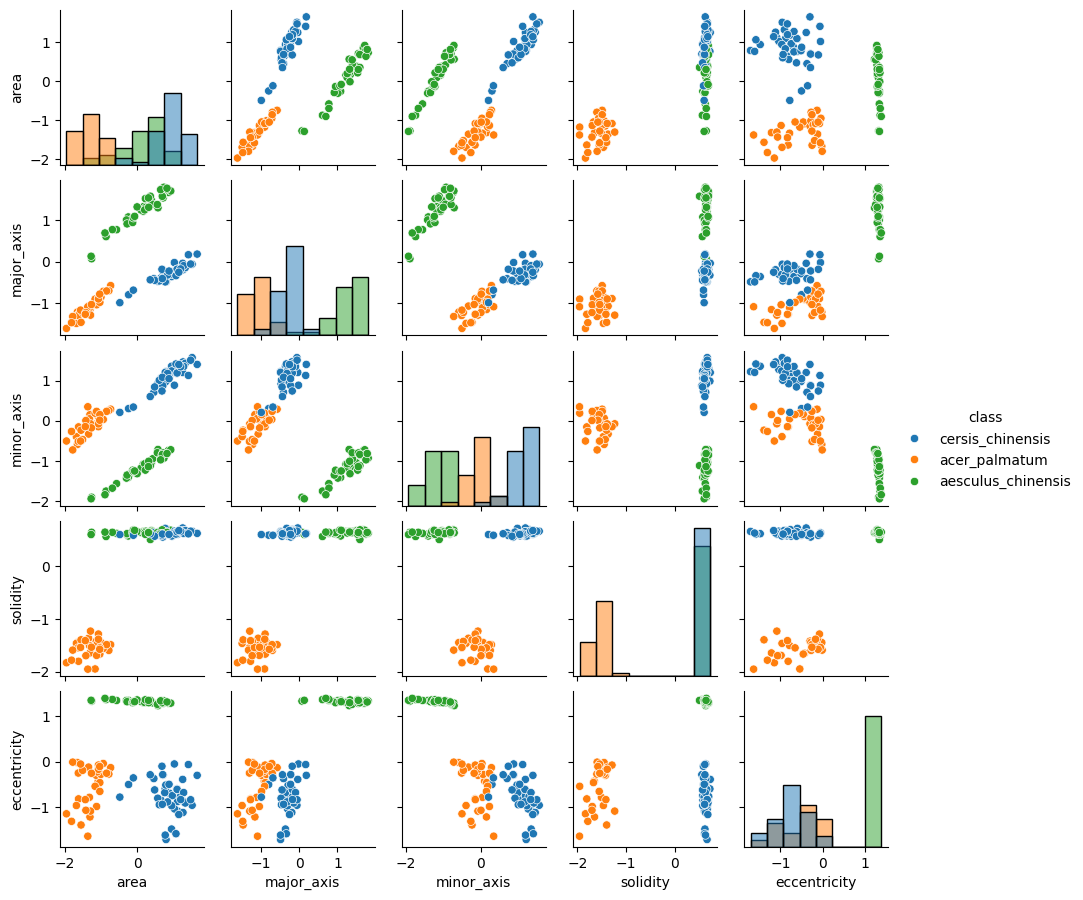

In [9]:
if dataset_name == 'flavia':
    g = sns.PairGrid(df, hue='class', vars=features)
    g.fig.set_size_inches(9, 9)
    g.map_diag(sns.histplot)
    g.map_offdiag(sns.scatterplot)
    g.add_legend()
    # sns.move_legend(g, "lower center", bbox_to_anchor=(0.5, -0.05), ncol=len(class_names))

else: # 'flowers'
    print("Feature visualization is not adequate for the 'flowers' dataset due to a large number of features.")

# Feature Selection

We select the features based sonely in the training set samples. 

In [10]:
if dataset_name == 'flavia':
    # Features
    ### selected_features = [0, 1] # area, major_axis - ** Easy **
    ### selected_features = [1, 4] # major_axis, eccentricity - ** Medium **
    selected_features = [0, 3] # area, solidity - ** Hard **

    # Select only two features for visualization  
    X_train_norm = X_train_norm[:,selected_features]
    X_val_norm = X_val_norm[:,selected_features]
    X_test_norm = X_test_norm[:,selected_features]

    
else: # 'flowers'
    # We will not apply feature selection for the 'flowers' dataset.
    print("We will not apply feature selection for the 'flowers' dataset.")

print(f"Shape of the training data: {X_train_norm.shape}")
print(f"Shape of the test data: {X_test_norm.shape}")

Shape of the training data: (114, 2)
Shape of the test data: (39, 2)


## Optimizing hyperparameters in the validation set
---

In [11]:
k_list = [1, 3, 5, 7, 9]

In [12]:
# Lists to store the accuracies
train_acc_list = []
val_acc_list = []

# Evaluate each candidate value of k
for k in k_list:
    # Create and train the k-NN classifier
    clf = neighbors.KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_norm, y_train)

    # Training accuracy
    y_train_pred = clf.predict(X_train_norm)
    train_acc = metrics.accuracy_score(y_train, y_train_pred)
    train_acc_list.append(train_acc)
    
    # Validation accuracy
    y_val_pred = clf.predict(X_val_norm)
    val_acc = metrics.accuracy_score(y_val, y_val_pred)
    val_acc_list.append(val_acc)

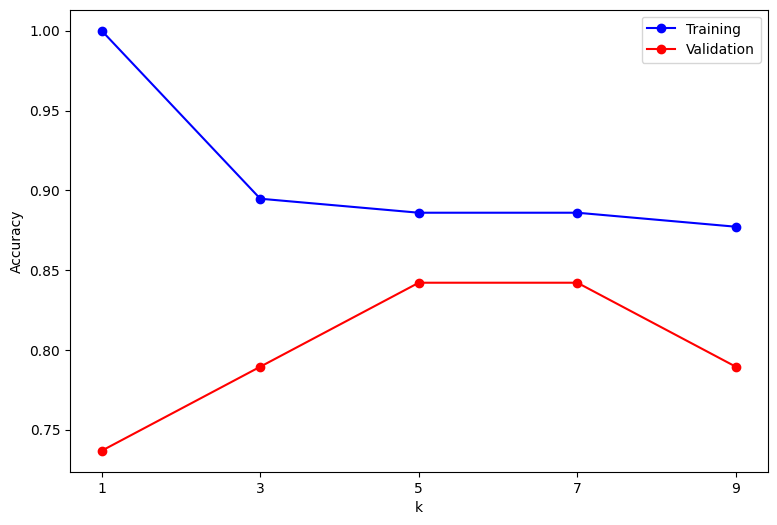

In [13]:
plt.figure(figsize=(9, 6))

plt.plot(k_list, train_acc_list, '-o', color='blue', label='Training')
plt.plot(k_list, val_acc_list, '-o', color='red', label='Validation')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.xticks(k_list)
plt.legend(loc='best')

plt.show()

### Which value of k should we select?

In [14]:
# Create a DataFrame with the results
results_df = pd.DataFrame({
    'k': k_list,
    'Training accuracy': train_acc_list,
    'Validation accuracy': val_acc_list
})

display(results_df.round(4))

,k,Training accuracy,Validation accuracy
0,1,1.0000,0.7368
1,3,0.8947,0.7895
2,5,0.8860,0.8421
3,7,0.8860,0.8421
4,9,0.8772,0.7895


In [15]:
# Select the k with the highest validation accuracy
best_idx = np.argmax(val_acc_list)
best_k = k_list[best_idx]

print(f"Best k: {best_k}")
print(f"Validation accuracy: {val_acc_list[best_idx]:.4f}")

Best k: 5
Validation accuracy: 0.8421


## Evaluating the Selected Model on the Test Set
---

After selecting the best value of `k` using the validation set, the selected model is evaluated on the test set to estimate its performance on unseen data.

In [16]:
# Create the k-NN classifier with the selected k
clf = neighbors.KNeighborsClassifier(n_neighbors=best_k)

# Train the classifier
clf.fit(X_train_norm, y_train)

# Predict the test set
y_pred = clf.predict(X_test_norm)

# Compute test accuracy
test_acc = metrics.accuracy_score(y_test, y_pred)

print(f'Test accuracy: {test_acc:.4f}')

Test accuracy: 0.8462


## Model Evaluation
---

The classifier performance is evaluated on the test set by comparing the predicted and true class labels. 

The confusion matrix and classification metrics are used to summarize the results.


Confusion matrix:
[[11  0  0]
 [ 0  8  5]
 [ 0  1 14]]

Confusion matrix visualization:


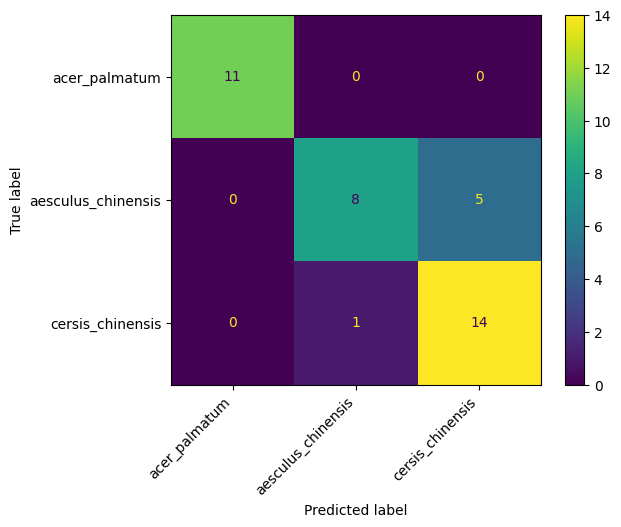

In [17]:
print('\nConfusion matrix:')
print(metrics.confusion_matrix(y_test, y_pred))


# Confusion matrix visualization
print('\nConfusion matrix visualization:')
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=class_names
)
plt.xticks(rotation=45, ha='right')
plt.show()

In [18]:
print('\nClassification report:')
print(metrics.classification_report(y_test, y_pred))


Classification report:
                    precision    recall  f1-score   support

     acer_palmatum       1.00      1.00      1.00        11
aesculus_chinensis       0.89      0.62      0.73        13
  cersis_chinensis       0.74      0.93      0.82        15

          accuracy                           0.85        39
         macro avg       0.88      0.85      0.85        39
      weighted avg       0.86      0.85      0.84        39



### A detailed classification report

In [19]:
results_df = pd.DataFrame({
    'Filename': file_test,
    'True class': y_test,
    'Predicted class': y_pred,
    'Correct': y_test == y_pred
})

results_df.index.name = 'Sample'

display(results_df)

,Filename,True class,Predicted class,Correct
Sample,,,,
0,1077.jpg,aesculus_chinensis,cersis_chinensis,False
1,1069.jpg,aesculus_chinensis,aesculus_chinensis,True
2,1162.jpg,cersis_chinensis,cersis_chinensis,True
3,1319.jpg,acer_palmatum,acer_palmatum,True
4,1290.jpg,acer_palmatum,acer_palmatum,True
5,1136.jpg,cersis_chinensis,cersis_chinensis,True
6,1157.jpg,cersis_chinensis,cersis_chinensis,True
7,1174.jpg,cersis_chinensis,cersis_chinensis,True
8,1145.jpg,cersis_chinensis,cersis_chinensis,True


In [20]:
# Count correct and incorrect predictions
correct = y_test == y_pred
n_correct = correct.sum()
n_incorrect = (~correct).sum()

print(f'Correct predictions:   {n_correct}')
print(f'Incorrect predictions: {n_incorrect}')

Correct predictions:   33
Incorrect predictions: 6


## License
---
Copyright (c) 2026 João Fernando Mari.

The Python source code and Jupyter Notebook are licensed under the MIT License.  
See the `LICENSE` file in the repository for details.

Third-party materials remain subject to the rights and licenses of their respective authors and owners.

## Bibliography
---
* GONZALEZ, R.C.; WOODS, R.E.; Digital Image Processing. 3rd Edition. Prentice Hall, 2008.
* DUDA, R.O.; HART, P.E.; STORK, D.G. Pattern Classification. 2nd Edition. Wiley-Interscience, 2001.
* COSTA, L. DA F.; CESAR-JR., R. M. Shape analysis and classification: theory and practice. CRC Press, 2000. Chapter 8.
* Scikit-image documentation.
    - https://scikit-image.org/docs/stable/
* scikit-learn - User Guide.
    * https://scikit-learn.org/stable/user_guide.html

Flavia Leaf Dataset:
* WU, S.G.;  BAO, F.S; XU, E.Y.; WANG, Y.-X.; CHANG, Y.-F.; XIANG, Q.-L. A Leaf Recognition Algorithm for Plant classification Using Probabilistic Neural Network. IEEE 7th International Symposium on Signal Processing and Information Technology, Dec. 2007, Cairo, Egypt.
    - https://doi.org/10.1109/ISSPIT.2007.4458016 
    - Flavia Leaf Dataset: https://flavia.sourceforge.net/  
